# 03_How_The_Algorithm_Works.ipynb

---

# Step-by-Step Workflow

Let's understand exactly what happens inside KNN when making a prediction.

Suppose our training dataset is:

| Height (cm) | Weight (kg) | Sport     |
| ----------- | ----------- | --------- |
| 170         | 65          | Football  |
| 172         | 68          | Football  |
| 160         | 52          | Badminton |
| 158         | 50          | Badminton |
| 175         | 70          | Football  |

Now a new person arrives:

```text
Height = 171
Weight = 66
```

We want to predict the sport.

---

## Step 1: Store the Training Data

Unlike Linear Regression or Logistic Regression, KNN does **not** calculate weights or coefficients.

Training simply means:

```text
Store all training samples in memory.
```

Memory contains:

```text
(170,65) → Football
(172,68) → Football
(160,52) → Badminton
(158,50) → Badminton
(175,70) → Football
```

No model equation is created.

---

## Step 2: Receive a New Query Point

New sample:

```text
(171,66)
```

This is called the **query point**.

---

## Step 3: Calculate Distance to Every Training Sample

Suppose we use **Euclidean Distance**.

For each training sample:

### Sample 1

```text
(170,65)
```

Distance:

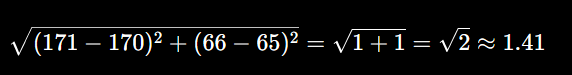

---

### Sample 2

```text
(172,68)
```

Distance:

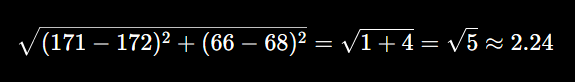

---

Suppose after computing all distances we get:

| Sample   | Distance | Sport     |
| -------- | -------- | --------- |
| (170,65) | 1.41     | Football  |
| (172,68) | 2.24     | Football  |
| (175,70) | 5.66     | Football  |
| (160,52) | 17.80    | Badminton |
| (158,50) | 20.62    | Badminton |

---

## Step 4: Sort by Distance

Arrange them from smallest to largest.

| Rank | Distance | Sport     |
| ---- | -------- | --------- |
| 1    | 1.41     | Football  |
| 2    | 2.24     | Football  |
| 3    | 5.66     | Football  |
| 4    | 17.80    | Badminton |
| 5    | 20.62    | Badminton |

---

## Step 5: Select the First K Neighbors

Suppose:

```text
K = 3
```

Neighbors become:

| Neighbor | Sport    |
| -------- | -------- |
| 1        | Football |
| 2        | Football |
| 3        | Football |

---

## Step 6A: Classification Prediction

Count votes.

```text
Football = 3

Badminton = 0
```

Prediction:

```text
Football
```

---

## Step 6B: Regression Prediction

Suppose the outputs were:

| Neighbor | Price |
| -------- | ----- |
| 1        | 50L   |
| 2        | 55L   |
| 3        | 52L   |

Prediction:

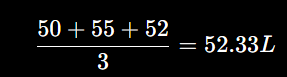

---

# Training Process

This is one of the easiest algorithms to train.

Training consists of only two tasks:

### Step 1

Receive dataset.

↓

### Step 2

Store dataset.

↓

Training completed.

---

### Pseudo Code

```python
def fit(X, y):
    self.X_train = X
    self.y_train = y
```

That's it.

Notice:

* No gradient descent
* No optimization
* No coefficients
* No cost function

---

# Prediction Process

Prediction is where almost all computation happens.

---

### Step 1

Receive new sample.

↓

### Step 2

Compute distance to every training sample.

↓

### Step 3

Sort all distances.

↓

### Step 4

Pick K nearest neighbors.

↓

### Step 5

If classification:

Majority Vote

If regression:

Average

↓

Return prediction.

---

### Pseudo Code

```python
for every training sample:
    compute distance

sort distances

pick first K

if classification:
    return majority vote

else:
    return average
```

---

# Flow Diagram

```text
                 Training Phase

Training Dataset
        │
        ▼
Store Dataset in Memory
        │
        ▼
Training Complete


-----------------------------------------------


               Prediction Phase

New Sample
     │
     ▼
Calculate Distance
to Every Training Sample
     │
     ▼
Sort Distances
     │
     ▼
Select K Nearest Neighbors
     │
     ▼
Classification? ───────► Majority Vote
        │
        │
        └──────────────► Regression?
                           Average
        │
        ▼
Return Prediction
```

---

# Small Numerical Example

Suppose we have only one feature.

Training Data:

| Age | Purchased |
| --- | --------- |
| 20  | No        |
| 22  | No        |
| 24  | Yes       |
| 30  | Yes       |
| 35  | Yes       |

Predict for:

```text
Age = 23
```

---

### Step 1

Compute distance.

| Age | Distance | Purchased |
| --- | -------- | --------- |
| 20  | 3        | No        |
| 22  | 1        | No        |
| 24  | 1        | Yes       |
| 30  | 7        | Yes       |
| 35  | 12       | Yes       |

---

### Step 2

Suppose

```text
K = 3
```

Nearest:

| Age | Purchased |
| --- | --------- |
| 22  | No        |
| 24  | Yes       |
| 20  | No        |

Votes:

```text
No = 2

Yes = 1
```

Prediction:

```text
No
```

---

Now suppose

```text
K = 5
```

Votes:

```text
No = 2

Yes = 3
```

Prediction changes to:

```text
Yes
```

### **Important Observation**

The prediction changed **only because K changed**.

This is why choosing the right value of **K** is so important.

---

# Visualization of Working

Imagine the following points:

```text
○ = Class A
● = Class B

            ○

      ○

                ?

          ●

    ●

         ●
```

Suppose:

```text
K = 3
```

Nearest neighbors:

```text
○

●

●
```

Votes:

```text
○ = 1

● = 2
```

Prediction:

```text
●
```

---

If

```text
K = 5
```

Neighbors:

```text
○

○

●

●

●
```

Votes:

```text
○ = 2

● = 3
```

Prediction remains:

```text
●
```

---

Another example:

```text
K = 1
```

Only the closest point matters.

```text
Nearest

○
```

Prediction:

```text
○
```

This makes KNN highly sensitive to noise.

---

# Algorithm Summary

## Training Phase

```text
Receive Dataset
        ↓
Store Dataset
        ↓
Training Complete
```

---

## Prediction Phase

```text
Receive Query Point
        ↓
Compute Distance to Every Training Sample
        ↓
Sort Distances
        ↓
Choose K Nearest Neighbors
        ↓
Classification?
        ↓
Majority Vote

OR

Regression?
        ↓
Average
        ↓
Return Prediction
```

---

## Time Spent

| Phase      | Time      |
| ---------- | --------- |
| Training   | Very Fast |
| Prediction | Slow      |

Reason:

* Training only stores data.
* Prediction compares the query with many stored samples.

---

## Key Takeaways

* KNN has **almost no training process**—it simply stores the training data.
* Every prediction requires:

  1. Computing distances,
  2. Sorting them,
  3. Selecting the **K nearest neighbors**.
* **Classification** uses majority voting.
* **Regression** uses the mean (or weighted mean) of the neighbors.
* The computational cost is shifted from **training** to **prediction**, making KNN a **lazy learning algorithm**.
* The choice of **K** can significantly change the prediction and the complexity of the decision boundary.